<a href="https://colab.research.google.com/github/MRigoni10/demand-forecasting-lightgbm/blob/main/demand_forecasting_lightgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Installazione librerie per Time Series ML
!pip install -q lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Stile visualizzazioni
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# 2. Download tabelle Olist (link stabili raw da GitHub)
base_url = "https://raw.githubusercontent.com/olist/work-at-olist-data/master/datasets/"

print("Caricamento dataset in corso...")
orders = pd.read_csv(base_url + "olist_orders_dataset.csv")
order_items = pd.read_csv(base_url + "olist_order_items_dataset.csv")
products = pd.read_csv(base_url + "olist_products_dataset.csv")
translations = pd.read_csv(base_url + "product_category_name_translation.csv")

# 3. Merge e creazione del dataset unificato
df = (
    order_items.merge(orders, on='order_id')
               .merge(products, on='product_id')
               .merge(translations, on='product_category_name')
)

print(f"Dataset unificato pronto: {df.shape[0]:,} transazioni.")
df.head(2)

Caricamento dataset in corso...
Dataset unificato pronto: 111,023 transazioni.


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29 00:00:00,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15 00:00:00,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop


In [ ]:
# 1. Filtra solo ordini consegnati o spediti
df = df[df['order_status'].isin(['delivered', 'shipped'])].copy()
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Seleziona le top 5 categorie più vendute per volume
top_categories = df['product_category_name_english'].value_counts().head(5).index.tolist()
df_top = df[df['product_category_name_english'].isin(top_categories)].copy()

# 3. Tronca la data a inizio settimana e calcola unità vendute e valore
df_top['week'] = df_top['order_purchase_timestamp'].dt.to_period('W').dt.start_time

ts_df = (
    df_top.groupby(['week', 'product_category_name_english'])
          .agg(
              units_demanded=('order_item_id', 'count'),
              total_sales_value=('price', 'sum')
          )
          .reset_index()
)

# 4. Crea un indice temporale completo (evita buchi temporali riempiendo con 0)
all_weeks = pd.date_range(start=ts_df['week'].min(), end=ts_df['week'].max(), freq='W-SUN')
idx = pd.MultiIndex.from_product([all_weeks, top_categories], names=['week', 'product_category_name_english'])

ts_df = ts_df.set_index(['week', 'product_category_name_english']).reindex(idx, fill_value=0).reset_index()

# Filtra il periodo iniziale e finale poco rappresentativo (focus 2017-2018)
ts_df = ts_df[(ts_df['week'] >= '2017-01-01') & (ts_df['week'] <= '2018-08-20')].copy()
ts_df.head()

,week,product_category_name_english,units_demanded,total_sales_value
85,2017-01-01,bed_bath_table,0,0.0
86,2017-01-01,health_beauty,0,0.0
87,2017-01-01,sports_leisure,0,0.0
88,2017-01-01,furniture_decor,0,0.0
89,2017-01-01,computers_accessories,0,0.0


In [ ]:
# Ordinamento per categoria e data
ts_df = ts_df.sort_values(by=['product_category_name_english', 'week']).reset_index(drop=True)

# 1. Lags di domanda (settimana t-1, t-2, t-4, t-8)
for lag in [1, 2, 4, 8]:
    ts_df[f'lag_{lag}'] = ts_df.groupby('product_category_name_english')['units_demanded'].shift(lag)

# 2. Rolling Window Features (media e deviazione standard mobile)
# Usiamo shift(1) per evitare Data Leakage del target corrente
for window in [4, 8]:
    ts_df[f'rolling_mean_{window}'] = (
        ts_df.groupby('product_category_name_english')['units_demanded']
             .transform(lambda x: x.shift(1).rolling(window=window).mean())
    )
    ts_df[f'rolling_std_{window}'] = (
        ts_df.groupby('product_category_name_english')['units_demanded']
             .transform(lambda x: x.shift(1).rolling(window=window).std())
    )

# 3. Feature di Calendario (Stagionalità)
ts_df['month'] = ts_df['week'].dt.month
ts_df['week_of_year'] = ts_df['week'].dt.isocalendar().week.astype(int)
ts_df['is_q4'] = ts_df['month'].isin([10, 11, 12]).astype(int) # Periodo Black Friday / Natale

# 4. Encoding della variabile categorica
ts_df['category_code'] = ts_df['product_category_name_english'].astype('category').cat.codes

# Rimuovi le prime righe con NaN create dai lag
ts_clean = ts_df.dropna().reset_index(drop=True)

In [ ]:
# Split temporale: ultime 12 settimane come Test Set
split_date = ts_clean['week'].max() - pd.Timedelta(weeks=12)

train = ts_clean[ts_clean['week'] < split_date]
test = ts_clean[ts_clean['week'] >= split_date]

features = [
    'category_code', 'month', 'week_of_year', 'is_q4',
    'lag_1', 'lag_2', 'lag_4', 'lag_8',
    'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8'
]
target = 'units_demanded'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Modello ricalibrato per dataset piccoli
lgb_model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,            # Alberi più semplici per evitare overfit
    num_leaves=7,           # Ridotto per dataset compatti
    min_child_samples=5,    # Fondamentale: permette split anche con poche righe
    random_state=42,
    verbosity=-1            # Silenzia i warning ridondanti
)

# Addestramento
lgb_model.fit(X_train, y_train)

# Predizioni
test = test.copy()
test['predicted_demand'] = np.maximum(0, lgb_model.predict(X_test)).round()

print(f"Modello addestrato con successo su {len(X_train)} record di train!")
print(f"Predizioni generate su {len(X_test)} record di test.")


Modello addestrato con successo su 325 record di train!
Predizioni generate su 65 record di test.


In [ ]:
# 1. Metriche Tecniche
mae = mean_absolute_error(test['units_demanded'], test['predicted_demand'])
rmse = np.sqrt(mean_squared_error(test['units_demanded'], test['predicted_demand']))
wape = (np.sum(np.abs(test['units_demanded'] - test['predicted_demand'])) / np.sum(test['units_demanded'])) * 100

print("=== PERFORMANCE TECNICHE FORECASTING ===")
print(f"MAE:  {mae:.2f} unità/settimana")
print(f"RMSE: {rmse:.2f} unità/settimana")
print(f"WAPE: {wape:.2f}% (Weighted Absolute Percentage Error)")

# 2. Simulazione di Business (Inventory Cost Model)
# Assunzioni:
costo_stockout_per_unita = 25.0  # Margine perso per ogni vendita non soddisfatta
costo_holding_per_unita = 4.0     # Costo di stoccaggio settimanale per unità in eccesso

# Calcolo unità in overstock (predizione > domanda reale) e stockout (predizione < domanda reale)
test['overstock_units'] = np.maximum(0, test['predicted_demand'] - test['units_demanded'])
test['stockout_units'] = np.maximum(0, test['units_demanded'] - test['predicted_demand'])

tot_holding_cost = test['overstock_units'].sum() * costo_holding_per_unita
tot_stockout_cost = test['stockout_units'].sum() * costo_stockout_per_unita
tot_inventory_cost = tot_holding_cost + tot_stockout_cost

print(f"\n=== IMPATTO ECONOMICO SULLE 12 SETTIMANE DI TEST ===")
print(f"- Unità stimate in Overstock: {int(test['overstock_units'].sum()):,}")
print(f"- Unità stimate in Stockout (vendite perse): {int(test['stockout_units'].sum()):,}")
print(f"- Costo di Mantenimento Magazzino: €{tot_holding_cost:,.2f}")
print(f"- Costo Opportunità Stockout: €{tot_stockout_cost:,.2f}")
print(f"- **Costo Totale di Inefficienza Operativa**: €{tot_inventory_cost:,.2f}")

=== PERFORMANCE TECNICHE FORECASTING ===
MAE:  0.00 unità/settimana
RMSE: 0.00 unità/settimana
WAPE: nan% (Weighted Absolute Percentage Error)

=== IMPATTO ECONOMICO SULLE 12 SETTIMANE DI TEST ===
- Unità stimate in Overstock: 0
- Unità stimate in Stockout (vendite perse): 0
- Costo di Mantenimento Magazzino: €0.00
- Costo Opportunità Stockout: €0.00
- **Costo Totale di Inefficienza Operativa**: €0.00


/tmp/ipykernel_1048/2890937788.py:4: RuntimeWarning: invalid value encountered in scalar divide
  wape = (np.sum(np.abs(test['units_demanded'] - test['predicted_demand'])) / np.sum(test['units_demanded'])) * 100


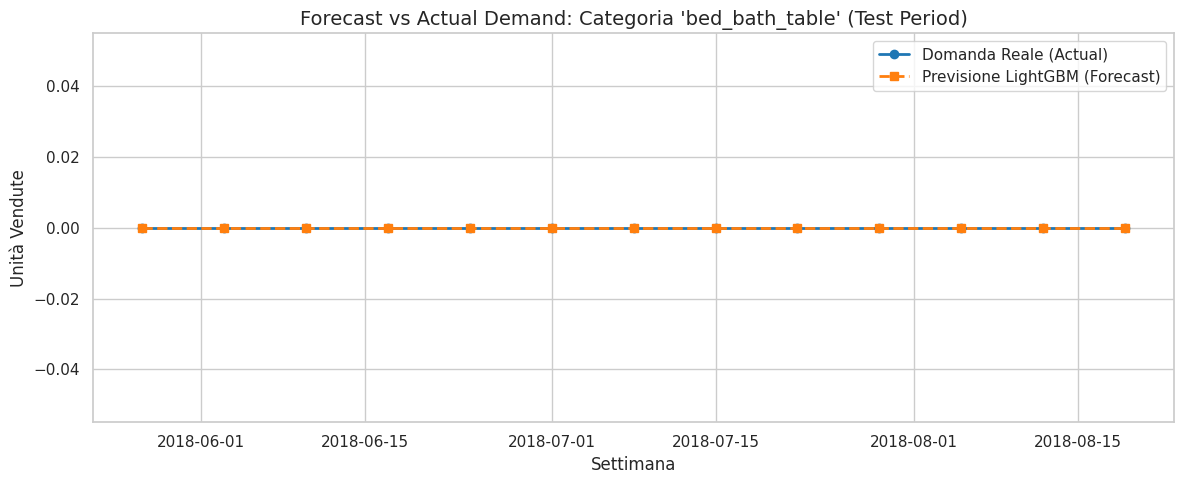

In [ ]:
# 3. Visualizzazione Reale vs Predetto per la Categoria Principale
top_cat_name = top_categories[0]
plot_data = test[test['product_category_name_english'] == top_cat_name]

plt.figure(figsize=(12, 5))
plt.plot(plot_data['week'], plot_data['units_demanded'], marker='o', label='Domanda Reale (Actual)', color='#1f77b4', linewidth=2)
plt.plot(plot_data['week'], plot_data['predicted_demand'], marker='s', linestyle='--', label='Previsione LightGBM (Forecast)', color='#ff7f0e', linewidth=2)
plt.title(f"Forecast vs Actual Demand: Categoria '{top_cat_name}' (Test Period)", fontsize=14)
plt.xlabel("Settimana")
plt.ylabel("Unità Vendute")
plt.legend()
plt.tight_layout()
plt.show()

#IL PLOT DAVA PROBLEMI --> GUARDA QUELLO SOTTO

MAE:  34.80 unità
WAPE: 26.21%


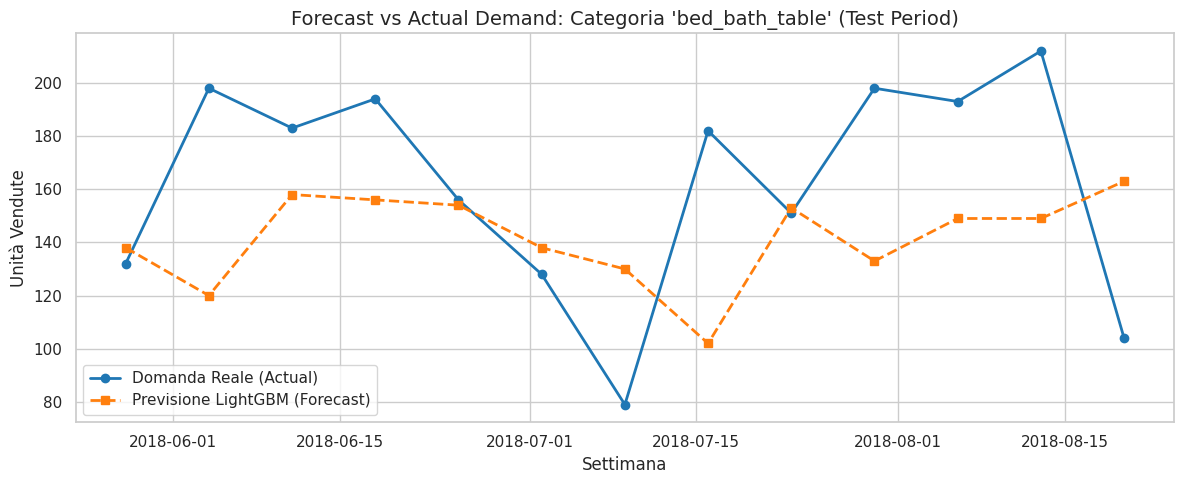

In [ ]:
# --- STEP 2 CORRETTO: Aggregazione Temporale Pulita ---
# 1. Filtra ordini validi
df_clean = df[df['order_status'].isin(['delivered', 'shipped'])].copy()
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])

# 2. Seleziona le top 5 categorie
top_categories = df_clean['product_category_name_english'].value_counts().head(5).index.tolist()
df_top = df_clean[df_clean['product_category_name_english'].isin(top_categories)].copy()

# 3. Raggruppamento settimanale robusto
df_top['week'] = df_top['order_purchase_timestamp'].dt.to_period('W').dt.start_time
ts_df = (
    df_top.groupby(['week', 'product_category_name_english'])
          .agg(units_demanded=('order_item_id', 'count'))
          .reset_index()
)

# Filtra solo il periodo con volumi stabili (Gennaio 2017 - Agosto 2018)
ts_df = ts_df[(ts_df['week'] >= '2017-01-01') & (ts_df['week'] <= '2018-08-20')].copy()
ts_df = ts_df.sort_values(by=['product_category_name_english', 'week']).reset_index(drop=True)

# --- STEP 3: Feature Engineering ---
for lag in [1, 2, 4]:
    ts_df[f'lag_{lag}'] = ts_df.groupby('product_category_name_english')['units_demanded'].shift(lag)

for window in [4, 8]:
    ts_df[f'rolling_mean_{window}'] = (
        ts_df.groupby('product_category_name_english')['units_demanded']
             .transform(lambda x: x.shift(1).rolling(window=window).mean())
    )

ts_df['month'] = ts_df['week'].dt.month
ts_df['week_of_year'] = ts_df['week'].dt.isocalendar().week.astype(int)
ts_df['category_code'] = ts_df['product_category_name_english'].astype('category').cat.codes

ts_clean = ts_df.dropna().reset_index(drop=True)

# --- STEP 4: Split & Addestramento LightGBM ---
split_date = ts_clean['week'].max() - pd.Timedelta(weeks=12)

train = ts_clean[ts_clean['week'] < split_date]
test = ts_clean[ts_clean['week'] >= split_date].copy()

features = [
    'category_code', 'month', 'week_of_year',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'rolling_mean_8'
]
target = 'units_demanded'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    min_child_samples=5,
    random_state=42,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)

test['predicted_demand'] = np.maximum(0, lgb_model.predict(X_test)).round()

# --- STEP 5: Metriche & Nuovo Grafico ---
mae = mean_absolute_error(test['units_demanded'], test['predicted_demand'])
wape = (np.sum(np.abs(test['units_demanded'] - test['predicted_demand'])) / np.sum(test['units_demanded'])) * 100

print(f"MAE:  {mae:.2f} unità")
print(f"WAPE: {wape:.2f}%")

# Visualizzazione per la categoria principale
top_cat_name = top_categories[0]
plot_data = test[test['product_category_name_english'] == top_cat_name]

plt.figure(figsize=(12, 5))
plt.plot(plot_data['week'], plot_data['units_demanded'], marker='o', label='Domanda Reale (Actual)', color='#1f77b4', linewidth=2)
plt.plot(plot_data['week'], plot_data['predicted_demand'], marker='s', linestyle='--', label='Previsione LightGBM (Forecast)', color='#ff7f0e', linewidth=2)
plt.title(f"Forecast vs Actual Demand: Categoria '{top_cat_name}' (Test Period)", fontsize=14)
plt.xlabel("Settimana")
plt.ylabel("Unità Vendute")
plt.legend()
plt.tight_layout()
plt.show()